# 03 距到期月成交量分布与累计分布

本 Notebook 复现论文 Appendix B Figures 11–12 和正文 Table 2：按两年样本段汇总每个品种在距退市月份 M0、M1、… 的成交量占比，计算反向累计成交量，并给出覆盖累计成交量 25%–75% 的离散月份区间。

数据只从正式 silver 湖仓读取；所有结果仅保存在 Notebook 输出中，不写入 silver、gold 或其他数据文件。

## 在做什么

对每个合约日，用交易日与该合约权威 `delist_date` 的年月差定义距到期月数；随后按“品种—两年样本段—距到期月”汇总全部固定月份合约的成交量。

- Figure 11 风格图回答：成交主要发生在距到期几个月？
- Figure 12 风格图回答：距到期至少 $k$ 个月的成交量还占多少？
- Table 2 风格表回答：从近到远累计时，中间 50% 成交量落在哪个月份区间？

## 经济意义

成交量向较小的距到期月集中，说明市场参与者更愿意在临近到期的合约上交易；反向累计曲线向左移动，和更快换月、近月流动性改善相容。25%–75% 区间越靠左或越窄，说明成交集中在更接近到期、范围更集中的合约月份。

这些统计是市场流动性期限结构的描述。曲线变化不能单独证明交易者更成熟，也不能直接归因于某项监管、算法交易或参与者结构变化。

## 论文口径

论文先定义距到期 \(k\) 个月内的成交量：

$$
V(k)=\sum_n\sum_{s:\,k-1\le M(s,T_n)\le k}v(s,T_n),
$$

其中 \(M(s,T_n)\) 是交易日 \(s\) 与合约到期日 \(T_n\) 之间的月数。Figure 11 展示 \(V(k)/\sum_lV(l)\)。

Figure 12 使用反向累计口径：

$$
\bar V(k)=\frac{\sum_{l\ge k}V(l)}{\sum_lV(l)}.
$$

因此曲线从 M0 的 100% 向右递减；曲线越靠左，论文解释为换月越快。默认比较 2012-13、2014-15、2016-17、2018-19 和 2020-21 五个两年样本段。

## 当前数据口径与适用边界

- 湖仓没有另一列独立的“标准到期日”；本 Notebook 以合约日历权威 `delist_date` 表示到期日。
- 距到期月固定按年月差计算：`(delist_year - trading_year) × 12 + delist_month - trading_month`，不解析合约代码猜测交割月。
- 同一合约日在日线表只有一行，在合约日历可能因日盘/夜盘 Session 有多行；先确认同一键只有一个 `delist_date`，再折叠到唯一合约日。
- 只纳入 `has_market_data=true` 且成交量大于 0 的记录；零成交不会改变总量，缺失或负成交量不进入分布。
- 25% 和 75% 端点是离散、成交量加权分位点：从 M0 向远月累计，取首次达到相应累计份额的月份。

## 代码步骤

1. 定位项目根目录，导入权威日线与合约日历 Schema。
2. 设置六品种和五个两年样本段。
3. 分别契约化读取日线成交量与合约日历 `delist_date`。
4. 折叠 Session、按唯一合约日连接并计算距到期月。
5. 计算成交量分布、反向累计分布和 25%–75% 区间。
6. 绘制 Figures 11–12 风格六面板图。
7. 人工复算每个有效品种—样本段并验证图表。

## 第 1 步：环境、根目录和权威 Schema

In [1]:
from __future__ import annotations

import pathlib
import sys
from datetime import date

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
from IPython.display import display

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()  # 当前工作目录

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")

PROJECT_ROOT = candidate_root

from config.data_contracts import (  # noqa: E402
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_DAILY_SCHEMA,
    arrow_to_pandas,
)
from config.settings import settings  # noqa: E402

print(f"project_root: {PROJECT_ROOT}")
print(f"python: {sys.executable}")
print(
    "schema_tables: "
    f"{FUTURES_DAILY_SCHEMA.metadata[b'table_name'].decode('utf-8')}, "
    f"{FUTURES_CONTRACT_CALENDAR_SCHEMA.metadata[b'table_name'].decode('utf-8')}"
)

project_root: E:\Latitude_Analytics_v2
python: E:\anaconda3\envs\latitude\python.exe
schema_tables: fact_futures_daily, dim_futures_contract_calendar


## 第 2 步：设置论文样本段

`ANALYSIS_PERIODS` 是唯一的时间参数。默认严格使用论文的五个两年段；如需扩展湖仓历史，可在此增加或修改互不重叠的样本段。

In [2]:
ANALYSIS_PERIODS = [
    {"label": "2012-13", "start_date": date(2012, 1, 1), "end_date": date(2013, 12, 31)},
    {"label": "2014-15", "start_date": date(2014, 1, 1), "end_date": date(2015, 12, 31)},
    {"label": "2016-17", "start_date": date(2016, 1, 1), "end_date": date(2017, 12, 31)},
    {"label": "2018-19", "start_date": date(2018, 1, 1), "end_date": date(2019, 12, 31)},
    {"label": "2020-21", "start_date": date(2020, 1, 1), "end_date": date(2021, 12, 31)},
]
PERIOD_LABELS = [period["label"] for period in ANALYSIS_PERIODS]
SAMPLE_START_DATE = min(period["start_date"] for period in ANALYSIS_PERIODS)
SAMPLE_END_DATE = max(period["end_date"] for period in ANALYSIS_PERIODS)

PRODUCTS = [
    {"exchange_code": "XSGE", "underlying_code": "RB", "label": "Steel Rebar"},
    {"exchange_code": "XSGE", "underlying_code": "CU", "label": "Copper"},
    {"exchange_code": "XSGE", "underlying_code": "NI", "label": "Nickel"},
    {"exchange_code": "XDCE", "underlying_code": "M", "label": "Soybean Meal"},
    {"exchange_code": "XDCE", "underlying_code": "L", "label": "Plastic"},
    {"exchange_code": "XDCE", "underlying_code": "C", "label": "Corn"},
]
PRODUCT_KEYS = [
    (product["exchange_code"], product["underlying_code"])
    for product in PRODUCTS
]
PRODUCT_LABEL_BY_KEY = {
    (product["exchange_code"], product["underlying_code"]): product["label"]
    for product in PRODUCTS
}

period_bounds_df = pd.DataFrame(ANALYSIS_PERIODS)
if (period_bounds_df["start_date"] > period_bounds_df["end_date"]).any():
    raise ValueError("样本段起点晚于终点")
ordered_period_bounds_df = period_bounds_df.sort_values("start_date").reset_index(drop=True)
if any(
    ordered_period_bounds_df.loc[index, "start_date"]
    <= ordered_period_bounds_df.loc[index - 1, "end_date"]
    for index in range(1, len(ordered_period_bounds_df))
):
    raise ValueError("样本段不能重叠")

display(pd.DataFrame(PRODUCTS))
display(period_bounds_df)

,exchange_code,underlying_code,label
0,XSGE,RB,Steel Rebar
1,XSGE,CU,Copper
2,XSGE,NI,Nickel
3,XDCE,M,Soybean Meal
4,XDCE,L,Plastic
5,XDCE,C,Corn


,label,start_date,end_date
0,2012-13,2012-01-01,2013-12-31
1,2014-15,2014-01-01,2015-12-31
2,2016-17,2016-01-01,2017-12-31
3,2018-19,2018-01-01,2019-12-31
4,2020-21,2020-01-01,2021-12-31


## 第 3 步：契约化读取两张 silver 表

表名、分区字段和列类型均来自权威 Schema。Dataset 过滤只下推目标交易所、六品种和论文样本日期；读取不扫描其他品种。

In [3]:
daily_metadata = {
    key.decode("utf-8"): value.decode("utf-8")
    for key, value in (FUTURES_DAILY_SCHEMA.metadata or {}).items()
}
calendar_metadata = {
    key.decode("utf-8"): value.decode("utf-8")
    for key, value in (FUTURES_CONTRACT_CALENDAR_SCHEMA.metadata or {}).items()
}
daily_path = settings.futures_lake_root / "silver" / daily_metadata["table_name"]
calendar_path = settings.futures_lake_root / "silver" / calendar_metadata["table_name"]
for table_path in [daily_path, calendar_path]:
    if not table_path.exists():
        raise FileNotFoundError(f"silver 表不存在：{table_path}")

daily_partition_columns = daily_metadata["partition_columns"].split(",")
calendar_partition_columns = calendar_metadata["partition_columns"].split(",")
daily_partitioning_schema = pa.schema(
    [
        pa.field(column_name, FUTURES_DAILY_SCHEMA.field(column_name).type)
        for column_name in daily_partition_columns
    ]
)
calendar_partitioning_schema = pa.schema(
    [
        pa.field(column_name, FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name).type)
        for column_name in calendar_partition_columns
    ]
)
daily_dataset = ds.dataset(
    daily_path,
    format="parquet",
    partitioning=ds.partitioning(daily_partitioning_schema, flavor="hive"),
)
calendar_dataset = ds.dataset(
    calendar_path,
    format="parquet",
    partitioning=ds.partitioning(calendar_partitioning_schema, flavor="hive"),
)

daily_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "volume",
    "has_market_data",
]
calendar_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delist_date",
]
daily_required_schema = pa.schema(
    [FUTURES_DAILY_SCHEMA.field(column_name) for column_name in daily_columns]
)
calendar_required_schema = pa.schema(
    [
        FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name)
        for column_name in calendar_columns
    ]
)
for required_schema, source_dataset in [
    (daily_required_schema, daily_dataset),
    (calendar_required_schema, calendar_dataset),
]:
    for expected_field in required_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if actual_field.type != expected_field.type:
            raise TypeError(
                f"字段 {expected_field.name} 类型不匹配："
                f"期望 {expected_field.type}，实际 {actual_field.type}"
            )

product_filter = None
for exchange_code, underlying_code in PRODUCT_KEYS:
    current_product_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
    )
    product_filter = (
        current_product_filter
        if product_filter is None
        else product_filter | current_product_filter
    )
date_filter = (
    (ds.field("trading_date") >= pa.scalar(SAMPLE_START_DATE))
    & (ds.field("trading_date") <= pa.scalar(SAMPLE_END_DATE))
)
filter_expression = product_filter & date_filter

selected_daily_table = daily_dataset.to_table(
    columns=daily_columns,
    filter=filter_expression,
)
selected_calendar_table = calendar_dataset.to_table(
    columns=calendar_columns,
    filter=filter_expression,
)
source_daily_df = arrow_to_pandas(selected_daily_table, daily_required_schema)
source_calendar_session_df = arrow_to_pandas(
    selected_calendar_table,
    calendar_required_schema,
)
for source_df in [source_daily_df, source_calendar_session_df]:
    source_df["trading_date"] = pd.to_datetime(source_df["trading_date"])
source_calendar_session_df["delist_date"] = pd.to_datetime(
    source_calendar_session_df["delist_date"]
)
source_daily_df["volume"] = pd.to_numeric(
    source_daily_df["volume"], errors="coerce"
).astype(float)

print(f"daily_path: {daily_path}")
print(f"calendar_path: {calendar_path}")
print(f"daily_rows: {len(source_daily_df):,}")
print(f"calendar_session_rows: {len(source_calendar_session_df):,}")

daily_path: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake\silver\fact_futures_daily
calendar_path: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake\silver\dim_futures_contract_calendar
daily_rows: 141,254
calendar_session_rows: 513,206


## 第 4 步：折叠 Session、连接到期日并计算距到期月

连接键是 `exchange_code + underlying_code + contract_code + trading_date`。在折叠日盘/夜盘 Session 前，先确认同一键没有多个不同 `delist_date`；然后要求日线与日历一对一完整匹配。

In [4]:
contract_day_keys = [
    "exchange_code",
    "underlying_code",
    "contract_code",
    "trading_date",
]
calendar_delist_count_df = (
    source_calendar_session_df.groupby(
        contract_day_keys,
        observed=True,
        dropna=False,
    )["delist_date"]
    .nunique(dropna=False)
    .reset_index(name="distinct_delist_dates")
)
calendar_delist_conflicts_df = calendar_delist_count_df.loc[
    calendar_delist_count_df["distinct_delist_dates"] != 1
]
if not calendar_delist_conflicts_df.empty:
    raise ValueError(
        "同一合约日存在缺失或冲突 delist_date："
        f"{len(calendar_delist_conflicts_df):,} 个键"
    )

contract_calendar_df = (
    source_calendar_session_df.sort_values(contract_day_keys)
    .drop_duplicates(contract_day_keys, keep="first")
    .reset_index(drop=True)
)
if contract_calendar_df.duplicated(contract_day_keys).any():
    raise AssertionError("合约日历折叠后仍有重复键")
if source_daily_df.duplicated(contract_day_keys).any():
    raise AssertionError("日线事实表在连接键上存在重复")

joined_contract_day_df = source_daily_df.merge(
    contract_calendar_df,
    on=contract_day_keys,
    how="left",
    validate="one_to_one",
    indicator=True,
)
join_status_counts = joined_contract_day_df["_merge"].value_counts(dropna=False)
unmatched_daily_df = joined_contract_day_df.loc[
    joined_contract_day_df["_merge"] != "both"
]
if not unmatched_daily_df.empty:
    raise ValueError(f"日线记录缺少合约日历匹配：{len(unmatched_daily_df):,} 行")

if (joined_contract_day_df["volume"].dropna() < 0).any():
    raise ValueError("来源日线存在负成交量")
joined_contract_day_df["period_label"] = pd.NA
for period in ANALYSIS_PERIODS:
    period_mask = joined_contract_day_df["trading_date"].between(
        pd.Timestamp(period["start_date"]),
        pd.Timestamp(period["end_date"]),
        inclusive="both",
    )
    joined_contract_day_df.loc[period_mask, "period_label"] = period["label"]

market_maturity_df = joined_contract_day_df.loc[
    joined_contract_day_df["has_market_data"].fillna(False)
    & joined_contract_day_df["volume"].notna()
    & (joined_contract_day_df["volume"] > 0)
    & joined_contract_day_df["delist_date"].notna()
    & joined_contract_day_df["period_label"].notna()
].copy()
market_maturity_df["months_to_maturity"] = (
    (
        market_maturity_df["delist_date"].dt.year
        - market_maturity_df["trading_date"].dt.year
    )
    * 12
    + market_maturity_df["delist_date"].dt.month
    - market_maturity_df["trading_date"].dt.month
).astype("int64")
if market_maturity_df.empty:
    raise ValueError("没有可用于距到期月分布的正成交量记录")
if (market_maturity_df["months_to_maturity"] < 0).any():
    raise ValueError("出现交易日晚于 delist_date 所在月份的记录")
if not np.isfinite(market_maturity_df["volume"].to_numpy(dtype=float)).all():
    raise ValueError("有效成交量包含非有限值")

available_product_keys = set(
    market_maturity_df[["exchange_code", "underlying_code"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
missing_product_keys = set(PRODUCT_KEYS) - available_product_keys
if missing_product_keys:
    raise AssertionError(f"目标品种无数据：{sorted(missing_product_keys)}")

coverage_df = (
    market_maturity_df.groupby(
        ["exchange_code", "underlying_code", "period_label"],
        observed=True,
        as_index=False,
    )
    .agg(
        first_trading_date=("trading_date", "min"),
        last_trading_date=("trading_date", "max"),
        positive_volume_contract_days=("contract_code", "size"),
        contracts=("contract_code", "nunique"),
        total_volume=("volume", "sum"),
        min_months_to_maturity=("months_to_maturity", "min"),
        max_months_to_maturity=("months_to_maturity", "max"),
    )
)
coverage_df["period_order"] = coverage_df["period_label"].map(
    {label: index for index, label in enumerate(PERIOD_LABELS)}
)
coverage_df["label"] = coverage_df.apply(
    lambda row: PRODUCT_LABEL_BY_KEY[
        (row["exchange_code"], row["underlying_code"])
    ],
    axis=1,
)
coverage_df = coverage_df.sort_values(
    ["exchange_code", "underlying_code", "period_order"]
).reset_index(drop=True)
display(
    coverage_df[
        [
            "exchange_code",
            "underlying_code",
            "label",
            "period_label",
            "first_trading_date",
            "last_trading_date",
            "positive_volume_contract_days",
            "contracts",
            "total_volume",
            "min_months_to_maturity",
            "max_months_to_maturity",
        ]
    ]
)
print(f"join_status: {join_status_counts.to_dict()}")
print(f"calendar_delist_conflicts: {len(calendar_delist_conflicts_df):,}")
print(f"positive_volume_contract_days: {len(market_maturity_df):,}")

,exchange_code,underlying_code,label,period_label,first_trading_date,last_trading_date,positive_volume_contract_days,contracts,total_volume,min_months_to_maturity,max_months_to_maturity
0,XDCE,C,Corn,2012-13,2012-01-04,2013-12-31,2698,18,1.022760e+08,0,12
1,XDCE,C,Corn,2014-15,2014-01-02,2015-12-31,2575,18,1.028403e+08,0,12
2,XDCE,C,Corn,2016-17,2016-01-04,2017-12-29,2848,18,4.993738e+08,0,12
3,XDCE,C,Corn,2018-19,2018-01-02,2019-12-31,2880,18,3.318636e+08,0,12
4,XDCE,C,Corn,2020-21,2020-01-02,2021-12-31,2874,18,3.669319e+08,0,12
5,XDCE,L,Plastic,2012-13,2012-01-04,2013-12-31,3324,34,2.880271e+08,0,12
6,XDCE,L,Plastic,2014-15,2014-01-02,2015-12-31,2647,35,3.832228e+08,0,12
7,XDCE,L,Plastic,2016-17,2016-01-04,2017-12-29,2212,35,3.247038e+08,0,12
8,XDCE,L,Plastic,2018-19,2018-01-02,2019-12-31,2033,35,2.003466e+08,0,12
9,XDCE,L,Plastic,2020-21,2020-01-02,2021-12-31,4460,35,2.346224e+08,0,12


join_status: {'both': 141254, 'left_only': 0, 'right_only': 0}
calendar_delist_conflicts: 0
positive_volume_contract_days: 121,162


## 第 5 步：成交量分布、反向累计与 25%–75% 区间

为每个实际有数据的“品种—样本段”补齐 M0 到样本最大月份的零成交桶。区间端点从近月向远月累计；反向累计则从远月向近月求和，两者方向不同。

In [5]:
period_volume_df = (
    market_maturity_df.groupby(
        [
            "exchange_code",
            "underlying_code",
            "period_label",
            "months_to_maturity",
        ],
        observed=True,
        as_index=False,
    )
    .agg(volume=("volume", "sum"))
)
max_observed_month = int(period_volume_df["months_to_maturity"].max())
month_grid = pd.DataFrame(
    {"months_to_maturity": np.arange(0, max_observed_month + 1, dtype=int)}
)

distribution_parts = []
interval_records = []
for product in PRODUCTS:
    product_key = (product["exchange_code"], product["underlying_code"])
    for period_label in PERIOD_LABELS:
        product_period_volume_df = period_volume_df.loc[
            (period_volume_df["exchange_code"] == product_key[0])
            & (period_volume_df["underlying_code"] == product_key[1])
            & (period_volume_df["period_label"] == period_label),
            ["months_to_maturity", "volume"],
        ].sort_values("months_to_maturity")
        if product_period_volume_df.empty:
            continue

        completed_distribution_df = month_grid.merge(
            product_period_volume_df,
            on="months_to_maturity",
            how="left",
            validate="one_to_one",
        )
        completed_distribution_df["volume"] = (
            completed_distribution_df["volume"].fillna(0.0)
        )
        total_volume = completed_distribution_df["volume"].sum()
        if not np.isfinite(total_volume) or total_volume <= 0:
            raise ValueError(f"品种—样本段总成交量无效：{product_key}, {period_label}")

        completed_distribution_df["volume_share"] = (
            completed_distribution_df["volume"] / total_volume
        )
        completed_distribution_df["near_to_far_cumulative_share"] = (
            completed_distribution_df["volume_share"].cumsum()
        )
        completed_distribution_df["reverse_cumulative_share"] = (
            completed_distribution_df["volume_share"]
            .iloc[::-1]
            .cumsum()
            .iloc[::-1]
        )
        completed_distribution_df["exchange_code"] = product_key[0]
        completed_distribution_df["underlying_code"] = product_key[1]
        completed_distribution_df["label"] = product["label"]
        completed_distribution_df["period_label"] = period_label
        distribution_parts.append(completed_distribution_df)

        q25_month = int(
            completed_distribution_df.loc[
                completed_distribution_df["near_to_far_cumulative_share"] >= 0.25,
                "months_to_maturity",
            ].iloc[0]
        )
        q75_month = int(
            completed_distribution_df.loc[
                completed_distribution_df["near_to_far_cumulative_share"] >= 0.75,
                "months_to_maturity",
            ].iloc[0]
        )
        interval_records.append(
            {
                "exchange_code": product_key[0],
                "underlying_code": product_key[1],
                "label": product["label"],
                "period_label": period_label,
                "q25_month": q25_month,
                "q75_month": q75_month,
                "middle_50pct_interval": (
                    str(q25_month)
                    if q25_month == q75_month
                    else f"{q25_month}-{q75_month}"
                ),
            }
        )

distribution_df = pd.concat(distribution_parts, ignore_index=True)
interval_df = pd.DataFrame(interval_records)
paper_style_table2_df = (
    interval_df.pivot(
        index=["exchange_code", "underlying_code", "label"],
        columns="period_label",
        values="middle_50pct_interval",
    )
    .reindex(
        pd.MultiIndex.from_tuples(
            [
                (
                    product["exchange_code"],
                    product["underlying_code"],
                    product["label"],
                )
                for product in PRODUCTS
            ],
            names=["exchange_code", "underlying_code", "label"],
        )
    )
    .reindex(columns=PERIOD_LABELS)
    .fillna("")
)
display(paper_style_table2_df)
print(f"max_observed_month: M{max_observed_month}")
print(f"available_product_periods: {len(interval_df):,}")

period_label                               2012-13 2014-15 2016-17 2018-19 2020-21
exchange_code underlying_code label                                               
XSGE          RB              Steel Rebar      4-6     4-6     3-6     3-5     3-5
              CU              Copper           3-4     2-3       2     1-2     1-2
              NI              Nickel                   2-4     2-5     2-3     2-3
XDCE          M               Soybean Meal     4-7     3-6     3-5     3-5     3-6
              L               Plastic          3-6     3-5     2-5     2-5     2-5
              C               Corn             4-7     4-7     3-6     3-5     3-5

max_observed_month: M12
available_product_periods: 29


## 第 6 步：绘制 Figure 11 风格成交量分布

横轴保留湖仓样本实际出现的完整 M0–M12，而不是按原论文图片的可见范围截断。每条线是一段两年样本内的成交量占比，六个面板各自使用合适的纵轴尺度。

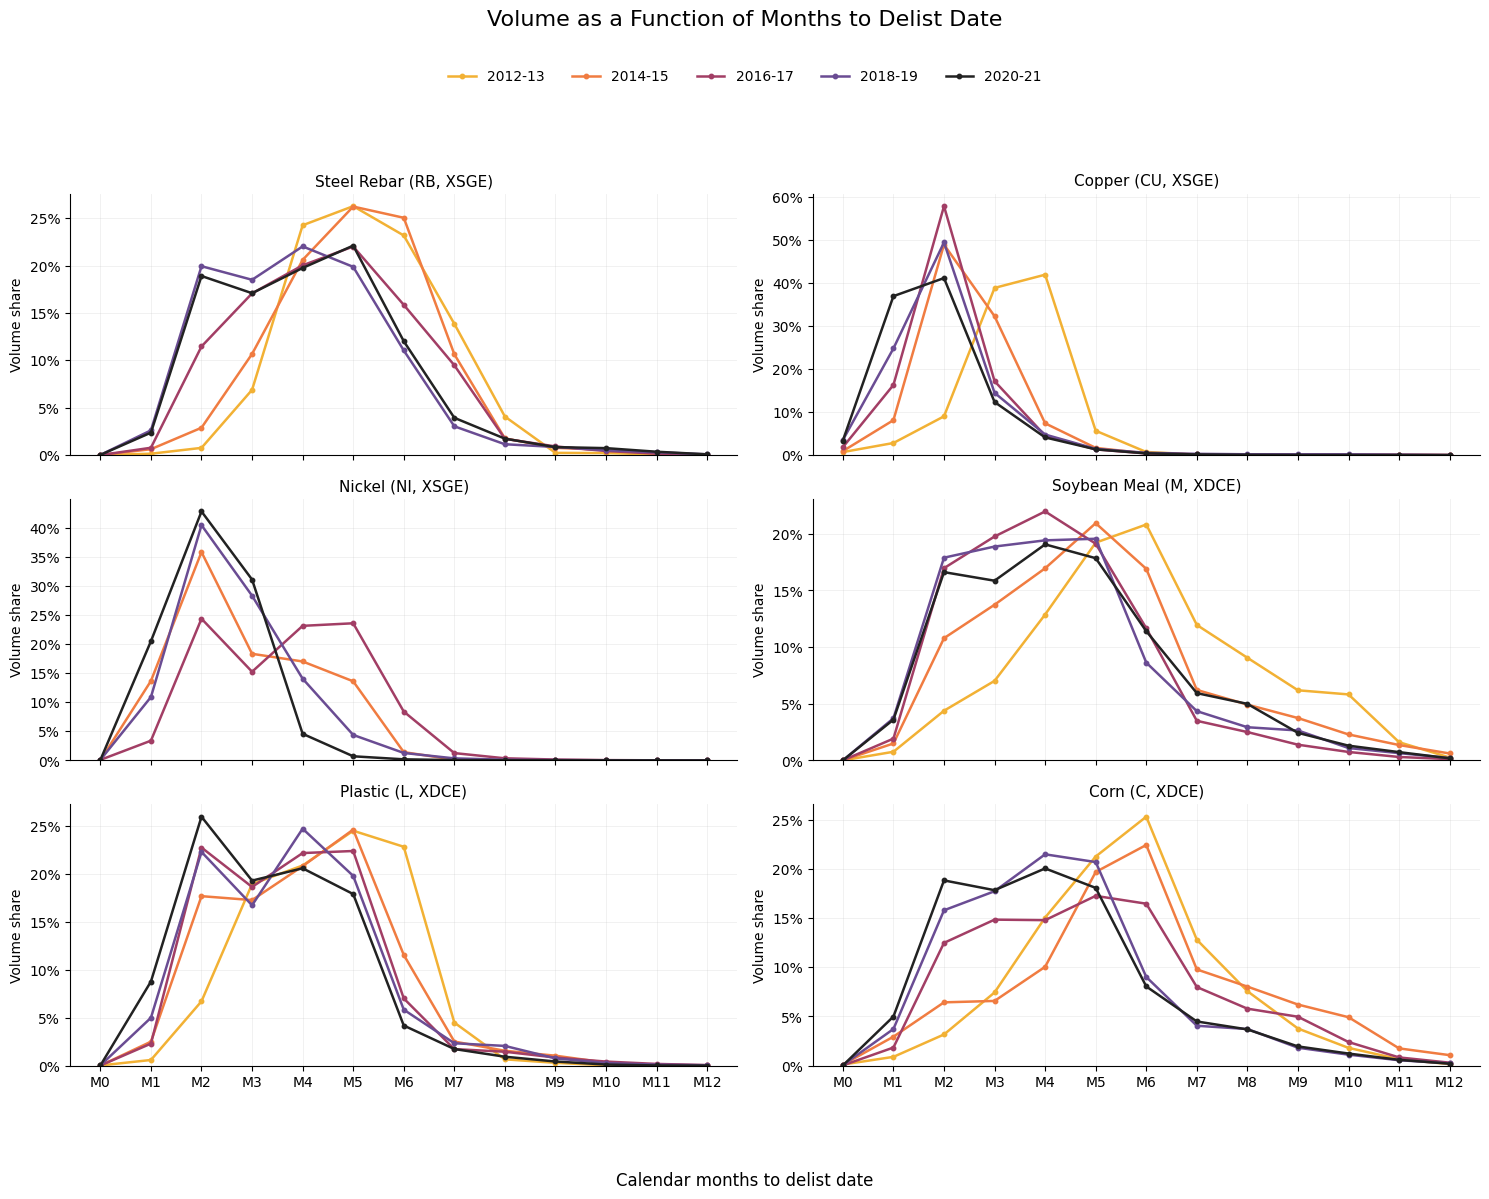

In [6]:
PERIOD_COLORS = {
    "2012-13": "#F2B134",
    "2014-15": "#F07C41",
    "2016-17": "#A23E65",
    "2018-19": "#6A4C93",
    "2020-21": "#222222",
}
fallback_period_colors = plt.colormaps["tab10"](
    np.linspace(0, 1, max(len(PERIOD_LABELS), 2))
)
for period_label, fallback_color in zip(PERIOD_LABELS, fallback_period_colors):
    PERIOD_COLORS.setdefault(period_label, fallback_color)

figure11, axes11 = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
figure11_legend_handles = []
for axis, product in zip(axes11.flat, PRODUCTS):
    product_key = (product["exchange_code"], product["underlying_code"])
    plotted_period_count = 0
    for period_label in PERIOD_LABELS:
        product_period_distribution_df = distribution_df.loc[
            (distribution_df["exchange_code"] == product_key[0])
            & (distribution_df["underlying_code"] == product_key[1])
            & (distribution_df["period_label"] == period_label)
        ].sort_values("months_to_maturity")
        if product_period_distribution_df.empty:
            continue
        line = axis.plot(
            product_period_distribution_df["months_to_maturity"],
            product_period_distribution_df["volume_share"] * 100,
            color=PERIOD_COLORS[period_label],
            linewidth=1.8,
            marker="o",
            markersize=3.2,
            label=period_label,
        )[0]
        if len(figure11_legend_handles) < len(PERIOD_LABELS):
            known_labels = [handle.get_label() for handle in figure11_legend_handles]
            if period_label not in known_labels:
                figure11_legend_handles.append(line)
        plotted_period_count += 1
    if plotted_period_count == 0:
        raise AssertionError(f"Figure 11 品种没有可绘制数据：{product_key}")

    axis.set_title(
        f"{product['label']} ({product['underlying_code']}, {product['exchange_code']})",
        fontsize=11,
    )
    axis.set_ylabel("Volume share")
    axis.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    axis.set_ylim(bottom=0)
    axis.set_xticks(range(0, max_observed_month + 1))
    axis.set_xticklabels([f"M{month}" for month in range(0, max_observed_month + 1)])
    axis.grid(alpha=0.2, linewidth=0.6)
    axis.spines[["top", "right"]].set_visible(False)

figure11.suptitle(
    "Volume as a Function of Months to Delist Date",
    fontsize=16,
    y=0.995,
)
figure11.supxlabel("Calendar months to delist date", y=0.012)
figure11.tight_layout(rect=(0, 0.055, 1, 0.90))
figure11.legend(
    sorted(figure11_legend_handles, key=lambda handle: PERIOD_LABELS.index(handle.get_label())),
    sorted([handle.get_label() for handle in figure11_legend_handles], key=PERIOD_LABELS.index),
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=5,
    frameon=False,
)
plt.show()

## 第 7 步：绘制 Figure 12 风格反向累计分布

M$k$ 点表示“距退市至少 $k$ 个月”的成交量占比。因此所有有效曲线从 M0 的 100% 开始并单调下降；曲线左移表示成交更早集中到临近退市月份。

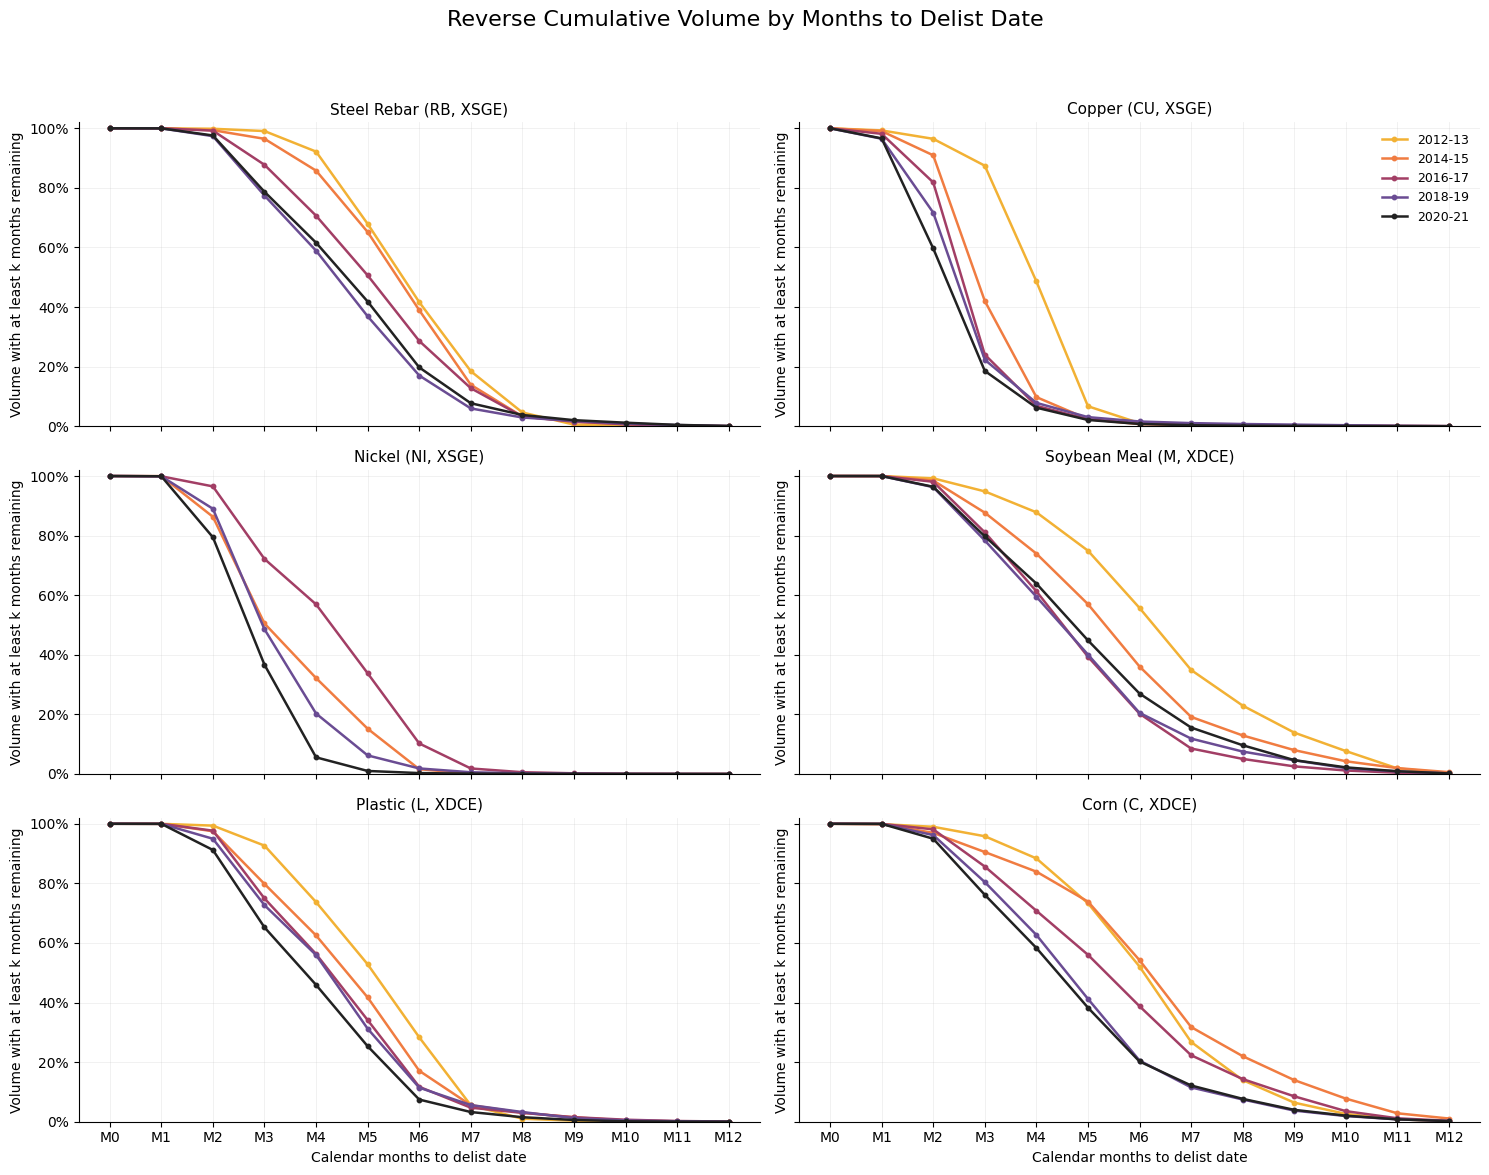

In [7]:
figure12, axes12 = plt.subplots(3, 2, figsize=(15, 12), sharex=True, sharey=True)
figure12_legend_handles = []
for axis, product in zip(axes12.flat, PRODUCTS):
    product_key = (product["exchange_code"], product["underlying_code"])
    plotted_period_count = 0
    for period_label in PERIOD_LABELS:
        product_period_distribution_df = distribution_df.loc[
            (distribution_df["exchange_code"] == product_key[0])
            & (distribution_df["underlying_code"] == product_key[1])
            & (distribution_df["period_label"] == period_label)
        ].sort_values("months_to_maturity")
        if product_period_distribution_df.empty:
            continue
        line = axis.plot(
            product_period_distribution_df["months_to_maturity"],
            product_period_distribution_df["reverse_cumulative_share"] * 100,
            color=PERIOD_COLORS[period_label],
            linewidth=1.8,
            marker="o",
            markersize=3.2,
            label=period_label,
        )[0]
        if len(figure12_legend_handles) < len(PERIOD_LABELS):
            known_labels = [handle.get_label() for handle in figure12_legend_handles]
            if period_label not in known_labels:
                figure12_legend_handles.append(line)
        plotted_period_count += 1
    if plotted_period_count == 0:
        raise AssertionError(f"Figure 12 品种没有可绘制数据：{product_key}")

    axis.set_title(
        f"{product['label']} ({product['underlying_code']}, {product['exchange_code']})",
        fontsize=11,
    )
    axis.set_ylabel("Volume with at least k months remaining")
    axis.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    axis.set_ylim(0, 102)
    axis.set_xticks(range(0, max_observed_month + 1))
    axis.set_xticklabels([f"M{month}" for month in range(0, max_observed_month + 1)])
    axis.grid(alpha=0.2, linewidth=0.6)
    axis.spines[["top", "right"]].set_visible(False)

axes12[0, 1].legend(loc="upper right", frameon=False, fontsize=9)
for bottom_axis in axes12[-1, :]:
    bottom_axis.set_xlabel("Calendar months to delist date")

figure12.suptitle(
    "Reverse Cumulative Volume by Months to Delist Date",
    fontsize=16,
    y=0.995,
)
figure12.tight_layout(rect=(0, 0.02, 1, 0.96))
plt.show()

## 验证

下面对每个实际有数据的品种—样本段直接从合约日明细重新汇总，复算总量、离散 25%/75% 端点和反向累计；同时验证六品种覆盖、NI 上市边界、概率和、单调性以及两张六面板图。

In [8]:
validated_product_periods = 0
for interval_row in interval_df.itertuples(index=False):
    product_period_contract_df = market_maturity_df.loc[
        (market_maturity_df["exchange_code"] == interval_row.exchange_code)
        & (market_maturity_df["underlying_code"] == interval_row.underlying_code)
        & (market_maturity_df["period_label"] == interval_row.period_label)
    ]
    manual_bucket_df = (
        product_period_contract_df.groupby(
            "months_to_maturity",
            observed=True,
            as_index=False,
        )
        .agg(volume=("volume", "sum"))
        .set_index("months_to_maturity")
        .reindex(range(0, max_observed_month + 1), fill_value=0.0)
        .reset_index()
    )
    manual_bucket_df["volume_share"] = (
        manual_bucket_df["volume"] / manual_bucket_df["volume"].sum()
    )
    manual_bucket_df["near_to_far_cumulative_share"] = (
        manual_bucket_df["volume_share"].cumsum()
    )
    manual_q25_month = int(
        manual_bucket_df.loc[
            manual_bucket_df["near_to_far_cumulative_share"] >= 0.25,
            "months_to_maturity",
        ].iloc[0]
    )
    manual_q75_month = int(
        manual_bucket_df.loc[
            manual_bucket_df["near_to_far_cumulative_share"] >= 0.75,
            "months_to_maturity",
        ].iloc[0]
    )
    if manual_q25_month != interval_row.q25_month:
        raise AssertionError(
            f"25% 端点复算不一致：{interval_row.exchange_code}, "
            f"{interval_row.underlying_code}, {interval_row.period_label}"
        )
    if manual_q75_month != interval_row.q75_month:
        raise AssertionError(
            f"75% 端点复算不一致：{interval_row.exchange_code}, "
            f"{interval_row.underlying_code}, {interval_row.period_label}"
        )

    product_period_distribution_df = distribution_df.loc[
        (distribution_df["exchange_code"] == interval_row.exchange_code)
        & (distribution_df["underlying_code"] == interval_row.underlying_code)
        & (distribution_df["period_label"] == interval_row.period_label)
    ].sort_values("months_to_maturity")
    if not np.isclose(
        product_period_distribution_df["volume_share"].sum(),
        1.0,
        rtol=1e-12,
        atol=1e-12,
    ):
        raise AssertionError("成交量占比之和不为 1")
    reverse_cumulative = product_period_distribution_df[
        "reverse_cumulative_share"
    ].to_numpy(dtype=float)
    if not np.isclose(reverse_cumulative[0], 1.0, rtol=1e-12, atol=1e-12):
        raise AssertionError("反向累计在 M0 不为 1")
    if (np.diff(reverse_cumulative) > 1e-12).any():
        raise AssertionError("反向累计曲线不是单调不增")
    validated_product_periods += 1

if len(available_product_keys) != len(PRODUCTS):
    raise AssertionError("有效品种数不是 6")
nickel_first_trading_date = market_maturity_df.loc[
    (market_maturity_df["exchange_code"] == "XSGE")
    & (market_maturity_df["underlying_code"] == "NI"),
    "trading_date",
].min()
if nickel_first_trading_date < pd.Timestamp("2015-01-01"):
    raise AssertionError("NI 在 2015 年上市前出现正成交量记录")
if len(axes11.flat) != len(PRODUCTS) or len(axes12.flat) != len(PRODUCTS):
    raise AssertionError("Figure 11 或 Figure 12 面板数不是 6")
figure12_legend = axes12[0, 1].get_legend()
if figure12_legend is None or len(figure12_legend.get_texts()) != len(PERIOD_LABELS):
    raise AssertionError("Figure 12 缺少五个样本段的可见图例")
if any(not axis.get_xlabel() for axis in axes12[-1, :]):
    raise AssertionError("Figure 12 底部面板缺少横轴标题")
if validated_product_periods != len(interval_df):
    raise AssertionError("有效品种—样本段验证数量不一致")

print(
    f"validation_ok: {len(available_product_keys)} products, "
    f"{validated_product_periods} product-periods, "
    f"{len(market_maturity_df):,} positive-volume contract-days, "
    f"{len(axes11.flat)} + {len(axes12.flat)} plot panels"
)
print(f"nickel_first_trading_date: {nickel_first_trading_date.date()}")

validation_ok: 6 products, 29 product-periods, 121,162 positive-volume contract-days, 6 + 6 plot panels
nickel_first_trading_date: 2015-03-27


## 如何解释结果

- Figure 11 的峰值月份表示两年样本段内最集中的成交位置；峰值向 M0 方向移动，表示成交更靠近退市月份。
- Figure 12 从 M0 的 100% 递减。较新的曲线如果整体向左，和论文所说的“换月更快”一致。
- Table 2 风格区间由本湖仓样本逐笔合约日成交量离散复算；它应与分布曲线一致，但由于这里用 `delist_date` 表示论文到期日，端点不要求逐格等于论文排版表。
- NI 在 2015 年上市，所以 2012-13 没有结果，2014-15 只包含上市后的有效记录；这不是缺数填零。
- 合约挂牌结构、交割制度和产业套保需求会影响不同品种的曲线，跨品种不能只按“越靠左越好”作价值判断。
- 所有结论是描述性的，不从同期共变直接推断监管或技术进步的因果作用。